In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, log_loss
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Data loading
train_df = pd.read_csv('/Users/wangwenze/Downloads/workshop/XGBoost/train.csv')
test_df = pd.read_csv('/Users/wangwenze/Downloads/workshop/XGBoost/test.csv')
sample_submission = pd.read_csv('/Users/wangwenze/Downloads/workshop/XGBoost/sample_submission.csv')

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
print("Sample submission file shape:", sample_submission.shape)

# Uniformly process the target variable format
train_df['Transported'] = train_df['Transported'].astype(bool)

Training set shape: (8693, 14)
Test set shape: (4277, 13)
Sample submission file shape: (4277, 2)


In [3]:
# 2. Exploratory Data Analysis
print("\nTraining set basic information:")
print(train_df.info())
print("\nTarget variable distribution:")
print(train_df['Transported'].value_counts())


Training set basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None

Target variable distribution:
Transported
True     4378
False    4315
Name: count, dtype: int64


In [4]:
# 3. Data preprocessing function
def preprocess_data(df, is_test=False):
    df_processed = df.copy()
    
    # 🔑 Core fix: When CryoSleep=True, all spending features must be 0 (original data contains dirty data)
    expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df_processed.loc[df_processed['CryoSleep'] == True, expense_cols] = 0
    
    # 🔑 [Repair Sequence] Basic features must be extracted first, followed by constructing derived features.
    if 'Name' in df_processed.columns:
        df_processed['LastName'] = df_processed['Name'].str.split(' ').str[-1]
        df_processed['FirstName'] = df_processed['Name'].str.split(' ').str[0]
        
    if 'Cabin' in df_processed.columns:
        df_processed['Cabin_deck'] = df_processed['Cabin'].str.split('/').str[0]
        df_processed['Cabin_num'] = pd.to_numeric(df_processed['Cabin'].str.split('/').str[1], errors='coerce')
        df_processed['Cabin_side'] = df_processed['Cabin'].str.split('/').str[2]
        # Missing value marking (Tree models explicitly learn whether missingness itself contains information)
        df_processed['Cabin_deck_is_miss'] = df_processed['Cabin_deck'].isnull().astype(int)
        df_processed['Cabin_num_is_miss'] = df_processed['Cabin_num'].isnull().astype(int)
        df_processed['Cabin_side_is_miss'] = df_processed['Cabin_side'].isnull().astype(int)
        
    # 🔑 Construct advanced features based on extracted features
    df_processed['Total_Spend'] = df_processed[expense_cols].sum(axis=1)
    if 'LastName' in df_processed.columns:
        name_counts = df_processed['LastName'].value_counts()
        df_processed['Is_Alone'] = (df_processed['LastName'].map(name_counts) == 1).astype(int)
        
    # 🔑 Fill missing values (median for numeric, mode for categorical, -1 for Cabin_num)
    numeric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_num', 'Total_Spend']
    for feature in numeric_features:
        if feature in df_processed.columns:
            df_processed[feature] = df_processed[feature].fillna(df_processed[feature].median())
            
    categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_deck', 'Cabin_side', 'LastName', 'FirstName']
    for feature in categorical_features:
        if feature in df_processed.columns:
            mode_val = df_processed[feature].mode()
            df_processed[feature] = df_processed[feature].fillna(mode_val[0] if not mode_val.empty else 'Unknown')
            
    passenger_ids = df_processed['PassengerId'] if 'PassengerId' in df_processed.columns else None
    df_processed.drop(['PassengerId', 'Cabin', 'Name'], axis=1, errors='ignore', inplace=True)
    
    return df_processed, passenger_ids

In [5]:
# 4. Data preprocessing
train_processed, _ = preprocess_data(train_df)
test_processed, test_passenger_ids = preprocess_data(test_df, is_test=True)

# Separate features and target variable
X = train_processed.drop(['Transported'], axis=1, errors='ignore')
y = train_df['Transported'].map({True: 1, False: 0})

print("X的形状:", X.shape)
print("y的形状:", y.shape)

X的形状: (8693, 20)
y的形状: (8693,)


/var/folders/2v/vxmhs25x03l375br_qdmwjzr0000gn/T/ipykernel_66382/3028612785.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_processed[feature] = df_processed[feature].fillna(mode_val[0] if not mode_val.empty else 'Unknown')
/var/folders/2v/vxmhs25x03l375br_qdmwjzr0000gn/T/ipykernel_66382/3028612785.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_processed[feature] = df_processed[feature].fillna(mode_val[0] if not mode_val.empty else 'Unknown')


In [6]:
# 5. Encode categorical variables
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", categorical_columns)

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    # Combine and fit to maintain consistent encoding space and avoid errors due to unseen categories in the test set.
    combined = pd.concat([X[col].astype(str), test_processed[col].astype(str)]).unique()
    le.fit(combined)
    
    X[col] = le.transform(X[col].astype(str))
    test_processed[col] = test_processed[col].apply(
        lambda x: le.transform([str(x)])[0] if str(x) in le.classes_ else -1
    )
    label_encoders[col] = le

print("Processed feature columns:", X.columns.tolist())

Categorical features: ['HomePlanet', 'Destination', 'LastName', 'FirstName', 'Cabin_deck', 'Cabin_side']
Processed feature columns: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'LastName', 'FirstName', 'Cabin_deck', 'Cabin_num', 'Cabin_side', 'Cabin_deck_is_miss', 'Cabin_num_is_miss', 'Cabin_side_is_miss', 'Total_Spend', 'Is_Alone']


In [7]:
# 6. Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

Training set size: (6954, 20)
Validation set size: (1739, 20)


In [8]:
# 7. Model training
xgb_model = xgb.XGBClassifier(
    n_estimators=5000,           # Give enough space, early stopping will automatically truncate
    max_depth=6,                 # Moderate depth to prevent overfitting
    learning_rate=0.02,          # Small learning rate to improve generalization
    subsample=0.8,               # Row sampling
    colsample_bytree=0.7,        # Column sampling
    reg_alpha=1.0,               # L1 regularization
    reg_lambda=3.0,              # L2 regularization
    min_child_weight=10,         # Minimum weight of leaf nodes
    gamma=0.15,                  # Minimum loss gain for splitting
    random_state=42,
    eval_metric='logloss',       # Common monitoring metrics for Kaggle
    early_stopping_rounds=50,    # More lenient early stopping tolerance
    tree_method='hist',
    verbosity=0
)

print("Start training the model (with early stopping)...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100                  # Print every 100 rounds
)

print(f"✅ Early stopping effective, actual number of trained trees: {xgb_model.best_iteration + 1}")

Start training the model (with early stopping)...
[0]	validation_0-logloss:0.68694
[100]	validation_0-logloss:0.43621
[200]	validation_0-logloss:0.39544
[300]	validation_0-logloss:0.38087
[400]	validation_0-logloss:0.37540
[500]	validation_0-logloss:0.37263
[600]	validation_0-logloss:0.37104
[700]	validation_0-logloss:0.37011
[705]	validation_0-logloss:0.37023
✅ Early stopping effective, actual number of trained trees: 656


In [9]:
# 8. 验证模型性能
y_pred = xgb_model.predict(X_val)
y_proba = xgb_model.predict_proba(X_val)[:, 1]
accuracy = accuracy_score(y_val, y_pred)
logloss = log_loss(y_val, y_proba)

print(f"\n验证集准确率: {accuracy:.4f}")
print(f"验证集 LogLoss: {logloss:.4f}")
print("\n详细分类报告:")
print(classification_report(y_val, y_pred))


验证集准确率: 0.8085
验证集 LogLoss: 0.3700

详细分类报告:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81       863
           1       0.80      0.82      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739




Top 10 Most Important Features:
         feature  importance
1      CryoSleep    0.303075
18   Total_Spend    0.137806
0     HomePlanet    0.099773
8            Spa    0.050290
6      FoodCourt    0.049116
12    Cabin_deck    0.048320
5    RoomService    0.047652
9         VRDeck    0.045898
7   ShoppingMall    0.037534
14    Cabin_side    0.032762


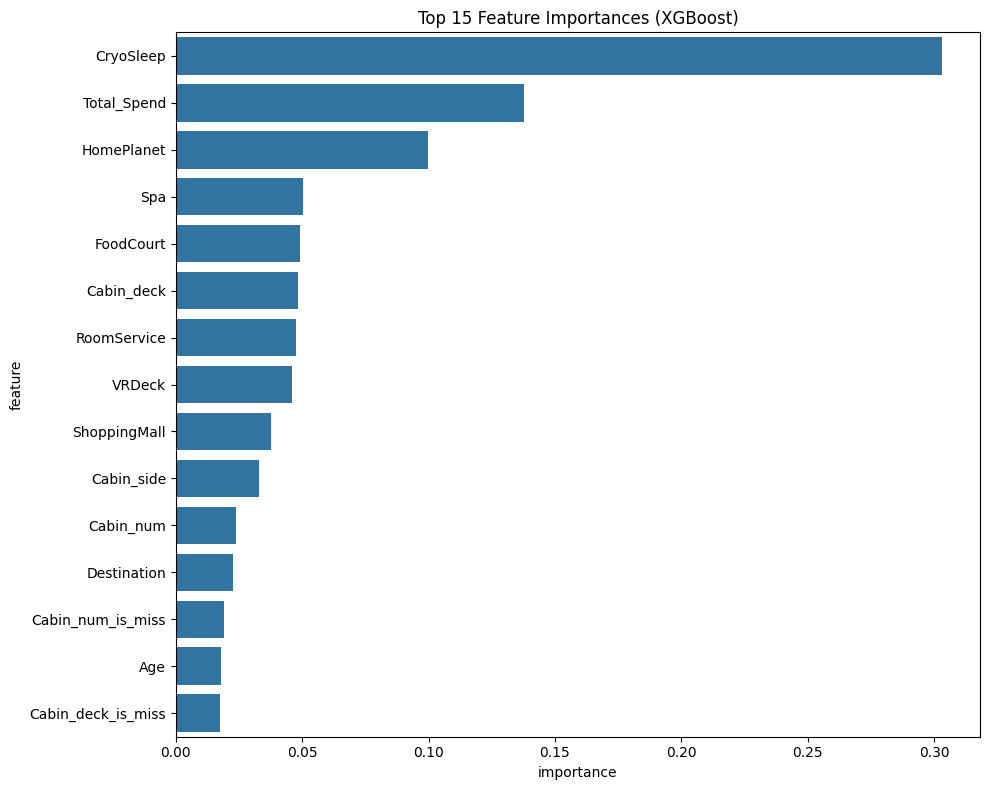

In [10]:
# 9. Feature Importance Analysis
feature_importance = xgb_model.feature_importances_
feature_names = X.columns

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

# Feature importance visualization
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

In [11]:
# 10. Predict Test Set
test_predictions_prob = xgb_model.predict_proba(test_processed)[:, 1]
test_predictions = (test_predictions_prob >= 0.5).astype(bool)  # Default threshold 0.5, can be fine-tuned later

In [12]:
# 11. Prepare Submission File
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': test_predictions.astype(bool)
})

# Save submission file
submission_path = '/Users/wangwenze/Downloads/workshop/XGBoost/submission_xgboost.csv'
submission.to_csv(submission_path, index=False)
print(f"\nSubmission file saved to: {submission_path}")
print(f"Prediction results distribution:")
print(submission['Transported'].value_counts())
print(f"First 5 rows of the submission file:")
print(submission.head())


Submission file saved to: /Users/wangwenze/Downloads/workshop/XGBoost/submission_xgboost.csv
Prediction results distribution:
Transported
True     2191
False    2086
Name: count, dtype: int64
First 5 rows of the submission file:
  PassengerId  Transported
0     0013_01        False
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True


In [13]:
# 12. Check if the submission file format is correct
sample_submission_format = pd.read_csv('/Users/wangwenze/Downloads/workshop/XGBoost/submission_xgboost.csv')
print(f"\nSample submission file format:")
print(sample_submission_format.head())
print(f"Submission file shape: {submission.shape}")
print(f"Sample file shape: {sample_submission_format.shape}")


Sample submission file format:
  PassengerId  Transported
0     0013_01        False
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
Submission file shape: (4277, 2)
Sample file shape: (4277, 2)
